In [1]:
import os
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import seaborn as sns
from pypalettes import load_cmap
from pylab import *

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- PDF structure: keep elements separate ---
    'pdf.compression': 0,         # prevents grouping/merging of vector paths
    'savefig.transparent': True,  # optional: preserves transparent backgrounds
    'savefig.bbox': 'tight',      # trims whitespace
    'savefig.pad_inches': 0.02,   # small padding for Illustrator bleed safety

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [2]:
#Priscilla ran the first comparisons using A/B/C etc cluster desgnations as used in Submission 1.0
#These can map back to leiden clusters using this dictionary
l_dict = {'A': 13,
 'C': 15,
 'B': 9,
 'D': 8,
 'F': 22,
 'E': 20,
 'G': 18,
 'H': 7,
 'I': 10,
 'N': 14,
 'J': 3,
 'K': 19,
 'M': 4,
 'L': 0,
  'MPP':23}

l_dict_r = {}

for key, value in l_dict.items():
    l_dict_r[value] = key

l_dict_r

{13: 'A',
 15: 'C',
 9: 'B',
 8: 'D',
 22: 'F',
 20: 'E',
 18: 'G',
 7: 'H',
 10: 'I',
 14: 'N',
 3: 'J',
 19: 'K',
 4: 'M',
 0: 'L',
 23: 'MPP'}

In [3]:
#First see what data is available in this run, all files are in ../Data/hallmarks
directory = '../Data/hallmarks/'

for i, fn in enumerate(os.listdir(directory)):
    pt = fn.split('_')[0]
    comp = fn.split('_')[1]
    comp1 = comp.split('vs')[0]
    comp2 = comp.split('vs')[1]
    if comp1 not in l_dict.keys():
        continue
    elif comp2 not in l_dict.keys():
        continue
    else:
            c1 = l_dict[comp1]
            c2 = l_dict[comp2]
            #print(fn, pt, comp, comp1, comp2, c1, c2)
        

In [4]:
#Import the data for leiden clusters into a single data frame - origibal set of comparisons
directory = '../Data/hallmarks/'
df_combined = None

for i, fn in enumerate(os.listdir(directory)):
    pt = fn.split('_')[0]
    comp = fn.split('_')[1]
    comp1 = comp.split('vs')[0]
    comp2 = comp.split('vs')[1]
    if comp1 not in l_dict.keys():
        continue
    elif comp2 not in l_dict.keys():
        continue
    else:
        c1 = l_dict[comp1]
        c2 = l_dict[comp2]
        comp3 = f'{c1}' + '_vs_' + f'{c2}'
        dir = fn.split('_')[3]
        if dir == 'up':
            info = 'UP in c1'
            fac = -1 #to plot on the left
        elif dir == 'down':
            info = 'UP in c2 (down in c1)'
            fac = 1 # to plot on the right
            
        file = os.path.join(directory, fn)
        df = pd.read_csv(file)
        df = df.loc[df['Adjusted P-value']<0.001] #Keep if the padj is significant
        df['n_genes'] = df['Overlap'].str.split('/').str[0]
        df['set_length'] = df['Overlap'].str.split('/').str[1]
        df['info'] = info
        df['pt_alias'] = pt
        df['comparison'] = comp
        df['comparison2'] = comp3
        df['Combined Score'] = df['Combined Score'] * fac  #make score negative for pathways UP in sensitive cluster
        df['pt_comp'] = df['pt_alias'] + '_' + df['comparison2']
        df['fraction'] = (df['n_genes'].astype('float')  / df['set_length'].astype('float')) * fac
        df['Odds Ratio'] = df['Odds Ratio'] * fac #make odds ratio negative for pathways UP in sensitive cluster
        df['Comp1_v0'] = comp1
        df['Comp2_v0'] = comp2
        df['Comp1_leiden'] = c1
        df['Comp2_leiden'] = c2
        df['x_coord'] = fac

        #TODO: check columns of interest
        df = df[['pt_alias', 'comparison', 'comparison2',  'Comp1_leiden', 'Comp2_leiden', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'n_genes', 'set_length', 'fraction', 'info', 'x_coord', 'Genes']].sort_values(['Combined Score'], ascending = False)        

        #print(fn, pt, comp, comp1, comp2, comp3, c1, c2, info, fac)

        if df_combined is None:
            df_combined = df.copy()
        else:
            df_combined = pd.concat([df_combined, df], ignore_index = True)

df_combined

,pt_alias,comparison,comparison2,Comp1_leiden,Comp2_leiden,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,n_genes,set_length,fraction,info,x_coord,Genes
0,P01,JvsN,3_vs_14,3,14,HALLMARK_MYC_TARGETS_V1,63/200,3.484923e-15,4.376002,162.709160,63,200,0.315000,UP in c2 (down in c1),1,PSMA4;MCM4;TXNL4A;MCM7;CUL1;KPNB1;EIF3B;RANBP1...
1,P01,JvsN,3_vs_14,3,14,HALLMARK_OXIDATIVE_PHOSPHORYLATION,59/200,5.355546e-13,3.940770,123.953558,59,200,0.295000,UP in c2 (down in c1),1,NDUFA7;SDHB;PMPCA;COX8A;TIMM13;TIMM8B;CYCS;IDH...
2,P01,JvsN,3_vs_14,3,14,HALLMARK_E2F_TARGETS,53/200,8.712419e-10,3.344124,79.102936,53,200,0.265000,UP in c2 (down in c1),1,MCM7;MCM4;RANBP1;PRIM2;CKS2;EZH2;MCM6;GSPT1;IL...
3,P01,JvsN,3_vs_14,3,14,HALLMARK_MTORC1_SIGNALING,44/200,1.194181e-05,2.559105,35.420554,44,200,0.220000,UP in c2 (down in c1),1,TPI1;PSMA4;MCM4;GSK3B;ACACA;HSPA5;SDF2L1;PSMB5...
4,P01,JvsN,3_vs_14,3,14,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,26/113,6.471904e-04,2.661188,25.129414,26,113,0.230088,UP in c2 (down in c1),1,SPCS3;SPCS1;HSPA5;EDC4;EDEM1;DNAJC3;NOLC1;SSR1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,P18,CvsB,15_vs_9,15,9,HALLMARK_CHOLESTEROL_HOMEOSTASIS,30/74,2.361624e-04,-2.842643,-29.766038,30,74,-0.405405,UP in c1,-1,NFIL3;PLSCR1;ACTG1;EBP;HMGCS1;SREBF2;JAG1;GNAI...
123,P18,CvsB,15_vs_9,15,9,HALLMARK_TGF_BETA_SIGNALING,27/54,6.787043e-06,-4.152885,-59.910451,27,54,-0.500000,UP in c1,-1,FKBP1A;CDK9;IFNGR2;SPTBN1;UBE2D3;ARID4B;TGFBR1...
124,P18,CvsB,15_vs_9,15,9,HALLMARK_IL2_STAT5_SIGNALING,77/199,3.402764e-09,-2.717487,-60.632810,77,199,-0.386935,UP in c1,-1,POU2F1;TNFRSF1B;TTC39B;KLF6;PLPP1;CDCP1;TIAM1;...
125,P18,CvsB,15_vs_9,15,9,HALLMARK_INTERFERON_GAMMA_RESPONSE,82/200,3.397726e-11,-3.013037,-82.328840,82,200,-0.410000,UP in c1,-1,CD69;CASP1;ICAM1;ZNFX1;ST8SIA4;IFI30;IFI35;BTG...


In [5]:
#Import the data for leiden clusters into a single data frame - extra set of comparisons
directory = '../Data/hallmarks_P01_extras/'


for i, fn in enumerate(os.listdir(directory)):
    if 'enrich' in fn:
        if '.csv' in fn:
            if 'hallmark' in fn:
                pt = fn.split('_')[0]
                comp = fn.split('_')[1]
                c1 = comp.split('vs')[0]
                c2 = comp.split('vs')[1]
                #print(pt, fn, comp, c1, c2)
                comp1 = l_dict_r[int(c1)]
                comp2 = l_dict_r[int(c2)]
                comp3 = f'{c1}' + '_vs_' + f'{c2}'
                comp4 = f'{comp1}' + 'vs' + f'{comp2}'
                dir = fn.split('_')[3]
                if dir == 'up':
                    info = 'UP in c1'
                    fac = -1 #to plot on the left
                elif dir == 'down':
                    info = 'UP in c2 (down in c1)'
                    fac = 1 # to plot on the right

                #print(fn, pt, comp, comp1, comp2, comp3, comp4, c1, c2, info, fac)
                        
                file = os.path.join(directory, fn)
                df = pd.read_csv(file)
                df = df.loc[df['Adjusted P-value']<0.001] #Keep if the padj is significant
                df['n_genes'] = df['Overlap'].str.split('/').str[0]
                df['set_length'] = df['Overlap'].str.split('/').str[1]
                df['info'] = info
                df['pt_alias'] = pt
                df['comparison'] = comp4
                df['comparison2'] = comp3
                df['Combined Score'] = df['Combined Score'] * fac  #make score negative for pathways UP in sensitive cluster
                df['pt_comp'] = df['pt_alias'] + '_' + df['comparison2']
                df['fraction'] = (df['n_genes'].astype('float')  / df['set_length'].astype('float')) * fac
                df['Odds Ratio'] = df['Odds Ratio'] * fac #make odds ratio negative for pathways UP in sensitive cluster
                df['Comp1_v0'] = comp1
                df['Comp2_v0'] = comp2
                df['Comp1_leiden'] = c1
                df['Comp2_leiden'] = c2
                df['x_coord'] = fac
        
                #TODO: check columns of interest
                df = df[['pt_alias', 'comparison', 'comparison2', 'Comp1_leiden', 'Comp2_leiden', 'Term', 'Overlap', 'Adjusted P-value', 'Odds Ratio', 'Combined Score', 'n_genes', 'set_length', 'fraction', 'info', 'x_coord','Genes']].sort_values(['Combined Score'], ascending = False)        
        
                #print(fn, pt, comp, comp1, comp2, comp3, c1, c2, info, fac)
        
                if df_combined is None:
                    df_combined = df.copy()
                else:
                    df_combined = pd.concat([df_combined, df], ignore_index = True)

df_combined

,pt_alias,comparison,comparison2,Comp1_leiden,Comp2_leiden,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,n_genes,set_length,fraction,info,x_coord,Genes
0,P01,JvsN,3_vs_14,3,14,HALLMARK_MYC_TARGETS_V1,63/200,3.484923e-15,4.376002,162.709160,63,200,0.315000,UP in c2 (down in c1),1,PSMA4;MCM4;TXNL4A;MCM7;CUL1;KPNB1;EIF3B;RANBP1...
1,P01,JvsN,3_vs_14,3,14,HALLMARK_OXIDATIVE_PHOSPHORYLATION,59/200,5.355546e-13,3.940770,123.953558,59,200,0.295000,UP in c2 (down in c1),1,NDUFA7;SDHB;PMPCA;COX8A;TIMM13;TIMM8B;CYCS;IDH...
2,P01,JvsN,3_vs_14,3,14,HALLMARK_E2F_TARGETS,53/200,8.712419e-10,3.344124,79.102936,53,200,0.265000,UP in c2 (down in c1),1,MCM7;MCM4;RANBP1;PRIM2;CKS2;EZH2;MCM6;GSPT1;IL...
3,P01,JvsN,3_vs_14,3,14,HALLMARK_MTORC1_SIGNALING,44/200,1.194181e-05,2.559105,35.420554,44,200,0.220000,UP in c2 (down in c1),1,TPI1;PSMA4;MCM4;GSK3B;ACACA;HSPA5;SDF2L1;PSMB5...
4,P01,JvsN,3_vs_14,3,14,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,26/113,6.471904e-04,2.661188,25.129414,26,113,0.230088,UP in c2 (down in c1),1,SPCS3;SPCS1;HSPA5;EDC4;EDEM1;DNAJC3;NOLC1;SSR1...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,P01,JvsMPP,3_vs_23,3,23,HALLMARK_MYC_TARGETS_V2,31/58,2.605975e-05,3.424745,42.424719,31,58,0.534483,UP in c2 (down in c1),1,LAS1L;PLK4;UNG;SUPV3L1;PPRC1;TCOF1;HSPE1;PLK1;...
141,P01,JvsMPP,3_vs_23,3,23,HALLMARK_DNA_REPAIR,68/150,4.314325e-07,2.526578,41.997463,68,150,0.453333,UP in c2 (down in c1),1,ZWINT;RFC3;GTF3C5;NUDT21;RFC2;RFC4;POLR2F;RBX1...
142,P01,JvsMPP,3_vs_23,3,23,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,48/113,2.573870e-04,2.222761,22.182554,48,113,0.424779,UP in c2 (down in c1),1,NFYB;DKC1;EIF4A3;LSM1;GEMIN4;SEC11A;SRPRA;NHP2...
143,P01,JvsMPP,3_vs_23,3,23,HALLMARK_INTERFERON_GAMMA_RESPONSE,18/200,1.617735e-04,-4.205563,-52.626323,18,200,-0.090000,UP in c1,-1,LYSMD2;HLA-DRB1;CD74;MVP;LCP2;SP110;VAMP5;IFIT...


In [6]:
#Now want to restrict to only the comparisons of interest - these are form the 30/11/25 figure 3 persist vs recede set
comps1 = {'P01':'3_vs_23',
        'P03': '8_vs_4',
        'P12': '22_vs_4',
        'P17': '4_vs_0',
        'P18': '13_vs_15',
        'P02': '18_vs_7',
        'P08': '19_vs_10'}

comps2 = {'P01': '3_vs_14',
        'P17': '19_vs_0',
        'P18': '13_vs_9',
        'P08': '19_vs_14'}

comps3 = {'P17': '4_vs_19', #actually want '19_vs_4'
        'P18': '15_vs_9',
        'P08': '14_vs_10'}

In [7]:
for key, value in comps1.items():
    data = df_combined.loc[df_combined['pt_alias']==key]
    comparisons = data['comparison2'].drop_duplicates().to_list()
    print(key, value)
    if value in comparisons:
        print(f'{value} is present')
    else:
        print(f'{value} not found')

for key, value in comps2.items():
    data = df_combined.loc[df_combined['pt_alias']==key]
    comparisons = data['comparison2'].drop_duplicates().to_list()
    print(key, value)
    if value in comparisons:
        print(f'{value} is present')
    else:
        print(f'{value} not found')

for key, value in comps3.items():
    data = df_combined.loc[df_combined['pt_alias']==key]
    comparisons = data['comparison2'].drop_duplicates().to_list()
    print(key, value)
    if value in comparisons:
        print(f'{value} is present')
    else:
        print(f'{value} not found')

#Can confirm all comparisons are present in the data except 19 vs 4 which is there in the wrong comparison direction ie/ 4 vs 19, will need to reverse

P01 3_vs_23
3_vs_23 is present
P03 8_vs_4
8_vs_4 is present
P12 22_vs_4
22_vs_4 is present
P17 4_vs_0
4_vs_0 is present
P18 13_vs_15
13_vs_15 is present
P02 18_vs_7
18_vs_7 is present
P08 19_vs_10
19_vs_10 is present
P01 3_vs_14
3_vs_14 is present
P17 19_vs_0
19_vs_0 is present
P18 13_vs_9
13_vs_9 is present
P08 19_vs_14
19_vs_14 is present
P17 4_vs_19
4_vs_19 is present
P18 15_vs_9
15_vs_9 is present
P08 14_vs_10
14_vs_10 is present


In [8]:
comp_list_orig = ['3_vs_23',
            '3_vs_14',
            '8_vs_4',
            '22_vs_4',
            '4_vs_0',
            '19_vs_0',
             '4_vs_19',
            '13_vs_15',
            '13_vs_9',
             '15_vs_9',
            '18_vs_7',
            '19_vs_10',
            '19_vs_14',
            '14_vs_10']

In [9]:
df_final = df_combined.loc[df_combined['comparison2'].isin(comp_list_orig)].copy()

In [10]:
df_final.loc[df_final['comparison2']=='4_vs_19']

,pt_alias,comparison,comparison2,Comp1_leiden,Comp2_leiden,Term,Overlap,Adjusted P-value,Odds Ratio,Combined Score,n_genes,set_length,fraction,info,x_coord,Genes
58,P17,MvsK,4_vs_19,4,19,HALLMARK_TNFA_SIGNALING_VIA_NFKB,35/200,2.120491e-04,2.658103,32.828932,35,200,0.175,UP in c2 (down in c1),1,JUNB;CD44;KLF6;IL18;PTGS2;TIPARP;SAT1;ZFP36;FO...
59,P17,MvsK,4_vs_19,4,19,HALLMARK_MYC_TARGETS_V1,44/200,2.479362e-09,-3.770115,-89.454603,44,200,-0.220,UP in c1,-1,KPNB1;CLNS1A;HSP90AB1;HNRNPA3;PSMD3;PSMD7;HNRN...


In [11]:
#Manually flip 'comparison2', 'info', 'x_coord'

#Original values
# df_final.loc[58, 'comparison2'] = '4_vs_19'
# df_final.loc[58, 'info'] = 'UP in c2 (down in c1)'
# df_final.loc[58, 'x_coord'] = 1
# df_final.loc[59, 'comparison2'] = '4_vs_19'
# df_final.loc[59, 'info'] = 'UP in c1'
# df_final.loc[59, 'x_coord'] = -1

df_final.loc[58, 'comparison2'] = '19_vs_4'
df_final.loc[58, 'info'] = 'UP in c1'
df_final.loc[58, 'x_coord'] = -1
df_final.loc[59, 'comparison2'] = '19_vs_4'
df_final.loc[59, 'info'] = 'UP in c2 (down in c1)'
df_final.loc[59, 'x_coord'] = 1

comp_list= ['3_vs_23',
            '3_vs_14',
            '8_vs_4',
            '22_vs_4',
            '4_vs_0',
            '19_vs_0',
             '19_vs_4',
            '13_vs_15',
            '13_vs_9',
             '15_vs_9',
            '18_vs_7',
            '19_vs_10',
            '19_vs_14',
            '14_vs_10']

In [12]:
#df_final.to_excel('../Figures/3_Hallmark_full_comparisons.xlsx', index=None)

In [13]:
#Most common terms up in more persistant cluster
df_final.loc[(df_final['info']=='UP in c1')]['Term'].value_counts()

Term
HALLMARK_INTERFERON_GAMMA_RESPONSE    6
HALLMARK_TNFA_SIGNALING_VIA_NFKB      6
HALLMARK_MYC_TARGETS_V1               6
HALLMARK_G2M_CHECKPOINT               5
HALLMARK_E2F_TARGETS                  5
HALLMARK_MITOTIC_SPINDLE              4
HALLMARK_UNFOLDED_PROTEIN_RESPONSE    4
HALLMARK_MTORC1_SIGNALING             4
HALLMARK_MYC_TARGETS_V2               4
HALLMARK_OXIDATIVE_PHOSPHORYLATION    4
HALLMARK_INTERFERON_ALPHA_RESPONSE    4
HALLMARK_APOPTOSIS                    3
HALLMARK_IL2_STAT5_SIGNALING          2
HALLMARK_PI3K_AKT_MTOR_SIGNALING      1
HALLMARK_UV_RESPONSE_UP               1
HALLMARK_HYPOXIA                      1
HALLMARK_ADIPOGENESIS                 1
HALLMARK_FATTY_ACID_METABOLISM        1
HALLMARK_DNA_REPAIR                   1
HALLMARK_HEME_METABOLISM              1
HALLMARK_ALLOGRAFT_REJECTION          1
HALLMARK_INFLAMMATORY_RESPONSE        1
HALLMARK_ANDROGEN_RESPONSE            1
HALLMARK_IL6_JAK_STAT3_SIGNALING      1
HALLMARK_CHOLESTEROL_HOMEOSTASIS   

In [14]:
#Most common terms up in more sensitive cluster
df_final.loc[(df_final['info']=='UP in c2 (down in c1)')]['Term'].value_counts()

Term
HALLMARK_MYC_TARGETS_V1                     8
HALLMARK_MTORC1_SIGNALING                   8
HALLMARK_OXIDATIVE_PHOSPHORYLATION          8
HALLMARK_E2F_TARGETS                        5
HALLMARK_G2M_CHECKPOINT                     5
HALLMARK_DNA_REPAIR                         5
HALLMARK_ADIPOGENESIS                       3
HALLMARK_UNFOLDED_PROTEIN_RESPONSE          3
HALLMARK_MYC_TARGETS_V2                     3
HALLMARK_HEME_METABOLISM                    2
HALLMARK_MITOTIC_SPINDLE                    2
HALLMARK_TNFA_SIGNALING_VIA_NFKB            2
HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY    1
HALLMARK_PROTEIN_SECRETION                  1
HALLMARK_IL2_STAT5_SIGNALING                1
HALLMARK_TGF_BETA_SIGNALING                 1
HALLMARK_ALLOGRAFT_REJECTION                1
HALLMARK_INTERFERON_ALPHA_RESPONSE          1
HALLMARK_APOPTOSIS                          1
HALLMARK_IL6_JAK_STAT3_SIGNALING            1
HALLMARK_CHOLESTEROL_HOMEOSTASIS            1
HALLMARK_HYPOXIA             

In [15]:
#Most common terms overall
df_final['Term'].value_counts()

Term
HALLMARK_MYC_TARGETS_V1                     14
HALLMARK_MTORC1_SIGNALING                   12
HALLMARK_OXIDATIVE_PHOSPHORYLATION          12
HALLMARK_E2F_TARGETS                        10
HALLMARK_G2M_CHECKPOINT                     10
HALLMARK_TNFA_SIGNALING_VIA_NFKB             8
HALLMARK_UNFOLDED_PROTEIN_RESPONSE           7
HALLMARK_INTERFERON_GAMMA_RESPONSE           7
HALLMARK_MYC_TARGETS_V2                      7
HALLMARK_MITOTIC_SPINDLE                     6
HALLMARK_DNA_REPAIR                          6
HALLMARK_INTERFERON_ALPHA_RESPONSE           5
HALLMARK_ADIPOGENESIS                        4
HALLMARK_APOPTOSIS                           4
HALLMARK_HEME_METABOLISM                     3
HALLMARK_IL2_STAT5_SIGNALING                 3
HALLMARK_CHOLESTEROL_HOMEOSTASIS             2
HALLMARK_FATTY_ACID_METABOLISM               2
HALLMARK_HYPOXIA                             2
HALLMARK_INFLAMMATORY_RESPONSE               2
HALLMARK_TGF_BETA_SIGNALING                  2
HALLMARK

In [16]:
#Most common terms overall
top12 = df_final['Term'].value_counts().head(12).index.to_list()
top12

['HALLMARK_MYC_TARGETS_V1',
 'HALLMARK_MTORC1_SIGNALING',
 'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
 'HALLMARK_E2F_TARGETS',
 'HALLMARK_G2M_CHECKPOINT',
 'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE',
 'HALLMARK_INTERFERON_GAMMA_RESPONSE',
 'HALLMARK_MYC_TARGETS_V2',
 'HALLMARK_MITOTIC_SPINDLE',
 'HALLMARK_DNA_REPAIR',
 'HALLMARK_INTERFERON_ALPHA_RESPONSE']

In [17]:
y_order_dict = dict(zip(df_final['Term'].value_counts().head(12).index, [11-i for i in range(12)]))
y_order_dict

{'HALLMARK_MYC_TARGETS_V1': 11,
 'HALLMARK_MTORC1_SIGNALING': 10,
 'HALLMARK_OXIDATIVE_PHOSPHORYLATION': 9,
 'HALLMARK_E2F_TARGETS': 8,
 'HALLMARK_G2M_CHECKPOINT': 7,
 'HALLMARK_TNFA_SIGNALING_VIA_NFKB': 6,
 'HALLMARK_UNFOLDED_PROTEIN_RESPONSE': 5,
 'HALLMARK_INTERFERON_GAMMA_RESPONSE': 4,
 'HALLMARK_MYC_TARGETS_V2': 3,
 'HALLMARK_MITOTIC_SPINDLE': 2,
 'HALLMARK_DNA_REPAIR': 1,
 'HALLMARK_INTERFERON_ALPHA_RESPONSE': 0}

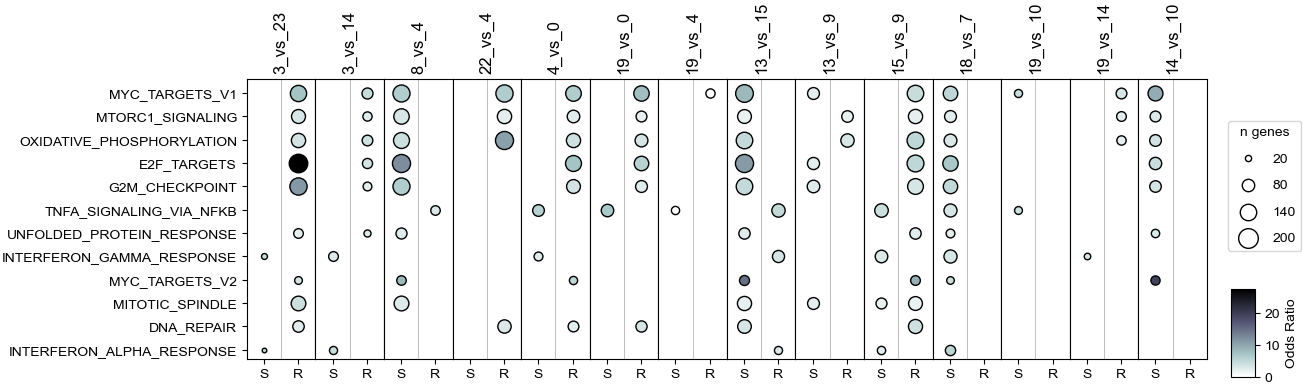

In [18]:
#Making the final plot for the paper

#loc the combined data to the desired pathways and plot. Chat helping with the point scaling
#Colouring by padj is a bit wild (all p values are very significant) Try Score instead

#Adjust ncomps if using manual list instead of plotting all comparisons
plot_list = top12
n_comps=len(comp_list)

fig, ax = plt.subplots(1, n_comps, figsize = (12,3.5))
min_padj = df_final.loc[(df_final['Term'].isin(plot_list))]['Adjusted P-value'].min()
max_score = df_final.loc[(df_final['Term'].isin(plot_list))]['Combined Score'].max()
max_or = df_final.loc[(df_final['Term'].isin(plot_list))]['Odds Ratio'].max()

# Define the scaling function - assumes that gene sets range from 20 - 200 genes
def scale_marker_size(x, min_val=20, max_val=200, min_size=20, max_size=200):
    return ((x - min_val) / (max_val - min_val)) * (max_size - min_size) + min_size

# cmapR = mpl.colormaps.get_cmap('bone_r')
# cmapS = mpl.colormaps.get_cmap('bone_r')
cmap = sns.color_palette("bone_r", as_cmap=True)


norm_p = mcolors.Normalize(vmin=0, vmax=min_padj)
norm_s = mcolors.Normalize(vmin=0, vmax=max_score)
norm_o = mcolors.Normalize(vmin=0, vmax=max_or)

for i, c in enumerate(comp_list):

    data = df_final.loc[(df_final['Term'].isin(plot_list)) & (df_final['comparison2']==c)]
    if data.empty:
        ax[i].set_xlim(-0.6, 0.6)
        ax[i].set_xticks([-0.3, 0.3])
        ax[i].set_xticklabels(['S', 'R'])
        ax[i].axvline(x=0, color = 'silver', linewidth = 0.5)
        ax[i].set_title(c, rotation=90)
        ax[i].set_yticklabels('')
        ax[i].set_yticks([])

    else:
        for j, row in data.iterrows():
            y = y_order_dict[row['Term']]
            ylabs = [k for k in y_order_dict.keys()]

            #Size for circles
            ngen = int(row['n_genes'])
            ngen_s = scale_marker_size(ngen)

            nset = int(row['set_length'])
            nset_s = scale_marker_size(nset)

            x = 0.3*row['x_coord']
            padj = row['Adjusted P-value']
            score = row['Combined Score']
            odr = row['Odds Ratio']*row['x_coord']
            color = cmap(norm_o(odr))

            ax[i].scatter(x,y,s = ngen_s, marker = 'o', color = color, edgecolor = 'k', zorder = 10) #plot the gene number
            #ax[i].scatter(x,y,s = nset_s, marker = 'o', color = 'white', edgecolor = 'black', linewidth = 0.5, zorder = 0) #plot the total gene set size
            ax[i].set_xlim(-0.6, 0.6)
            ax[i].set_xticks([-0.3, 0.3])
            ax[i].set_xticklabels(['S', 'R'])
            ax[i].axvline(x=0, color = 'silver', linewidth = 0.5)
            ax[i].set_ylim(-0.4, len(plot_list)-0.4)
            ax[i].set_yticks(np.arange(0,len(plot_list),1))
            ax[i].set_title(c, rotation=90)
            if i == 0:
                ax[i].set_yticklabels([k.split('_', 1)[1] for k in list(reversed(y_order_dict.keys()))])
                
            else:
                ax[i].set_yticklabels('')
                ax[i].set_yticks([])

#sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_p) #padj
#sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_s) #score
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_o) #odds ratio
sm.set_array([])  # required for colorbar to work without error
cax = fig.add_axes([0.92, 0.05, 0.02, 0.25])
fig.colorbar(sm, cax=cax, label='Odds Ratio')

plt.subplots_adjust(left=0.1, right=0.9, 
                    top=0.9, bottom=0.1, 
                    wspace=0, hspace=0.4)

#Legend for dot size
legend_values = [20, 80, 140, 200]
legend_sizes = [scale_marker_size(v) for v in legend_values]
# Create the legend handles
handles = [plt.scatter([], [], s=s, color='white', edgecolor = 'k', label=str(v))
           for v, s in zip(legend_values, legend_sizes)]

plt.legend(
    handles=handles,
    title="n genes",
    scatterpoints=1,
    loc='upper left',
    bbox_to_anchor=(-0.4, 3),  # x=1.05 puts it just outside the right edge, y=0.5 centers vertically
    labelspacing=1
)

#fig.savefig('../Figures/3_Hallmark_cluster_DEG_dotplots_v1.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

In [19]:
#Sumary data for interpretation - enriched in more persistant cluster
ep = pd.DataFrame(df_final.loc[(df_final['comparison2'].isin(comp_list)) & (df_final['Term'].isin(top12)) & (df_final['x_coord']==1)]['Term'].value_counts()).reset_index()
ep.columns = ['Term', 'Persistant']
ep

,Term,Persistant
0,HALLMARK_MYC_TARGETS_V1,8
1,HALLMARK_OXIDATIVE_PHOSPHORYLATION,8
2,HALLMARK_MTORC1_SIGNALING,8
3,HALLMARK_E2F_TARGETS,5
4,HALLMARK_G2M_CHECKPOINT,5
5,HALLMARK_DNA_REPAIR,5
6,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,3
7,HALLMARK_MYC_TARGETS_V2,3
8,HALLMARK_TNFA_SIGNALING_VIA_NFKB,2
9,HALLMARK_MITOTIC_SPINDLE,2


In [20]:
#Sumary data for interpretation - enriched in more receding cluster
er = pd.DataFrame(df_final.loc[(df_final['comparison2'].isin(comp_list)) & (df_final['Term'].isin(top12)) & (df_final['x_coord']==-1)]['Term'].value_counts()).reset_index()
er.columns = ['Term', 'Receding']
er

,Term,Receding
0,HALLMARK_INTERFERON_GAMMA_RESPONSE,6
1,HALLMARK_TNFA_SIGNALING_VIA_NFKB,6
2,HALLMARK_MYC_TARGETS_V1,6
3,HALLMARK_G2M_CHECKPOINT,5
4,HALLMARK_E2F_TARGETS,5
5,HALLMARK_INTERFERON_ALPHA_RESPONSE,4
6,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,4
7,HALLMARK_MTORC1_SIGNALING,4
8,HALLMARK_MYC_TARGETS_V2,4
9,HALLMARK_OXIDATIVE_PHOSPHORYLATION,4


In [21]:
erp = er.merge(ep, on='Term')
erp['Difference'] = erp.Receding - erp.Persistant
erp.sort_values(by='Difference')

,Term,Receding,Persistant,Difference
7,HALLMARK_MTORC1_SIGNALING,4,8,-4
9,HALLMARK_OXIDATIVE_PHOSPHORYLATION,4,8,-4
11,HALLMARK_DNA_REPAIR,1,5,-4
2,HALLMARK_MYC_TARGETS_V1,6,8,-2
3,HALLMARK_G2M_CHECKPOINT,5,5,0
4,HALLMARK_E2F_TARGETS,5,5,0
6,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,4,3,1
8,HALLMARK_MYC_TARGETS_V2,4,3,1
10,HALLMARK_MITOTIC_SPINDLE,4,2,2
5,HALLMARK_INTERFERON_ALPHA_RESPONSE,4,1,3
